In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv('../data/pjme_clean.csv', index_col='datetime', parse_dates=True)

df_daily = df.resample('D').mean().reset_index()
df_daily.columns = ['ds', 'y']

print(f"Shape: {df_daily.shape}")
df_daily.head()

/Users/furkan/Projeler/energy-consumption-forecasting/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Shape: (6059, 2)


,ds,y
0,2002-01-01,31080.739130
1,2002-01-02,34261.541667
2,2002-01-03,34511.875000
3,2002-01-04,33715.458333
4,2002-01-05,30405.125000


In [2]:
split_date = '2018-01-01'
train = df_daily[df_daily['ds'] < split_date]
test = df_daily[df_daily['ds'] >= split_date]

print(f"Train: {len(train)} days")
print(f"Test: {len(test)} days")

Train: 5844 days
Test: 215 days


In [3]:

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,  
    changepoint_prior_scale=0.05
)

model.fit(train)

future = model.make_future_dataframe(periods=len(test), freq='D')
forecast = model.predict(future)

print("Model fitted successfully")
print(f"Changepoints detected: {len(model.changepoints)}")

11:03:58 - cmdstanpy - INFO - Chain [1] start processing
11:04:00 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully
Changepoints detected: 25


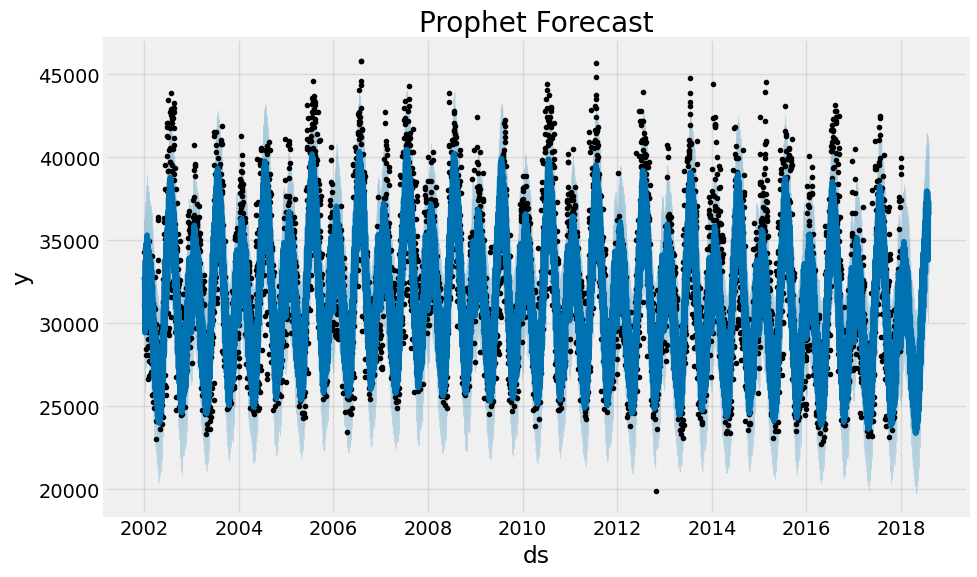

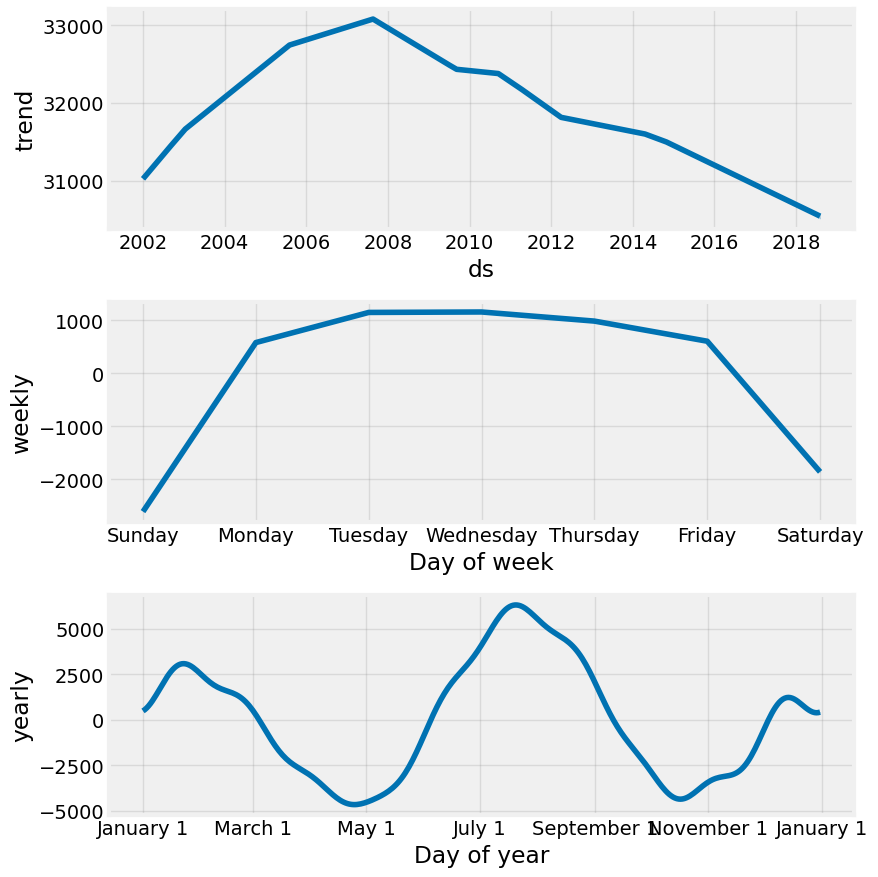

In [4]:
fig1 = model.plot(forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.show()

fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [5]:
forecast_test = forecast[forecast['ds'] >= split_date]

y_true = test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

MAE:  2478.80 MW
RMSE: 3368.26 MW
MAPE: 7.50%


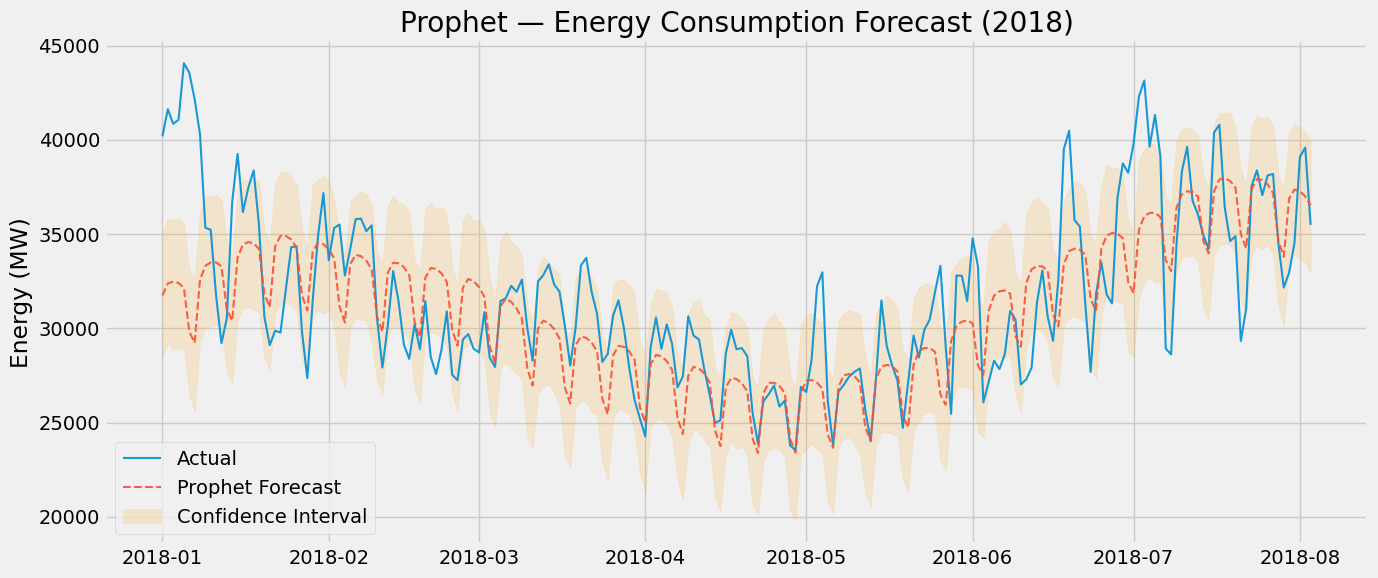

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test['ds'].values, y_true, label='Actual', alpha=0.9, linewidth=1.5)
ax.plot(test['ds'].values, y_pred, label='Prophet Forecast', linestyle='--', alpha=0.9, linewidth=1.5)
ax.fill_between(
    forecast_test['ds'].values,
    forecast_test['yhat_lower'].values,
    forecast_test['yhat_upper'].values,
    alpha=0.15, color='orange', label='Confidence Interval'
)
ax.set_title('Prophet — Energy Consumption Forecast (2018)')
ax.set_ylabel('Energy (MW)')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
model_tuned = Prophet(
    yearly_seasonality=20,
    weekly_seasonality=10,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=15,
    seasonality_mode='multiplicative'
)

model_tuned.add_country_holidays(country_name='US')

model_tuned.fit(train)

forecast_tuned = model_tuned.predict(future)
forecast_test_tuned = forecast_tuned[forecast_tuned['ds'] >= split_date]

y_pred_tuned = forecast_test_tuned['yhat'].values

mae_t = mean_absolute_error(y_true, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_true, y_pred_tuned))
mape_t = mean_absolute_percentage_error(y_true, y_pred_tuned) * 100

print("--- Baseline vs Tuned ---")
print(f"Baseline → MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
print(f"Tuned    → MAE: {mae_t:.2f} | RMSE: {rmse_t:.2f} | MAPE: {mape_t:.2f}%")

11:04:57 - cmdstanpy - INFO - Chain [1] start processing
11:04:58 - cmdstanpy - INFO - Chain [1] done processing


--- Baseline vs Tuned ---
Baseline → MAE: 2478.80 | RMSE: 3368.26 | MAPE: 7.50%
Tuned    → MAE: 2461.39 | RMSE: 3328.25 | MAPE: 7.41%


In [8]:
best_mae = min(mae, mae_t)
best_rmse = min(rmse, rmse_t)
best_mape = min(mape, mape_t)
best_preds = y_pred if mae < mae_t else y_pred_tuned
best_label = 'Baseline' if mae < mae_t else 'Tuned'

results_df = pd.DataFrame({
    'actual': y_true,
    'predicted': best_preds
}, index=test['ds'].values)
results_df.to_csv('../results/prophet_results.csv')

metrics = {
    'model': f'Prophet ({best_label})',
    'MAE': best_mae,
    'RMSE': best_rmse,
    'MAPE': best_mape
}
pd.DataFrame([metrics]).to_csv('../results/prophet_metrics.csv', index=False)

print(f"Saved best model: Prophet ({best_label})")

Saved best model: Prophet (Tuned)
